# Spinless Fermionic Hopping Model with Open Boundaries

**Note**: This notebook follows the exact same structure as the first one, with the aim to see how different Hamiltonians perform under Trotterization and qDRIFT. The mathematical foundations are therfore omitted, but can be found in the first notebook as well as the implementation in the source files. Only phenomena particular to the Fermionic model will be discussed here.


We consider a one-dimensional spinless fermionic hopping model with open boundary conditions (no loop). This can be written in terms of fermionic creation and annihilation operators, with a hopping amplitude J:

$$ H = -J \sum_i^{N-2} (c_i^{\dagger}c_{i+1} +c_{i+1}^{\dagger}c_i)$$

The nearest neighbour hopping terms can be mapped onto qubit operators using the Jordan-Wigner transformation. This is the representation we will be using.

$$H = -\frac{J}{2}\sum_i^{N-2}(X_iX_{i+1}+Y_iY_{i+1})$$

This Hamiltonian is particle number conserving, unlike the transverse field Ising Hamiltonian used in the previous notebook, and is a combination of XX and YY operators.

## Goal

We will follow the same procedure as for the Ising Hamiltonian, i.e. compare the exact solution to the three approximations via simulation accuracy and circuit cost. What will be interesting to look at is the qDRIFT and Trotterization behaviour for a different Hamiltonian structure and compare the two.

In [61]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.linalg import expm
from qiskit.quantum_info import Statevector

from hamiltonian_simulation.fermion import ferm_hop_hamiltonian
from hamiltonian_simulation.ferm_trotter import (ferm_first_trotterization, ferm_second_trotterization)
from hamiltonian_simulation.qdrift import qDrift

Again, we will start with a chain of four qubits. We will set $J=1$ and simulate the time up to $t=2$. We will not use the complete 0 state as the initial state here as we want to see some sort of "hopping" (particle number is conserved). We will use:
$$ \ket{\psi(t)} = e^{-iHt}\ket{\psi(t=0)} \,\,\,\, and\,\,\,\, \ket{\psi(0)} = \ket{1010} $$

In [62]:
n_qubits = 4
J=1
t=2

In [63]:
#Create a basis state for an n_qubit system
def psi0_ferm(n_qubits):
    bit =[]

    for i in range(n_qubits):
        if i%2==0:
            bit.append("0")
        else:
            bit.append("1")

    return(Statevector.from_label("".join(bit)))

psi0 = psi0_ferm(n_qubits)
H_ferm = ferm_hop_hamiltonian(J, n_qubits)
H = H_ferm.to_matrix()

#Create exact time evolution
U = expm(-1j*H*t)
psi_t = U @ psi0.data

def infidelity(psi_exact, psi_approx):
    overlap = np.vdot(psi_exact, psi_approx)
    return 1- np.abs(overlap)**2

print(H_ferm)

SparsePauliOp(['XXII', 'IXXI', 'IIXX', 'YYII', 'IYYI', 'IIYY'],
              coeffs=[-0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j, -0.5+0.j])


## Trotterization and qDRIFT 

In this section we will jump right into the infidelity vs the step count. The approach will be the same as in the first notebook.

In [64]:
step_num = [1, 2, 5, 10, 50, 100, 200, 500]


#### Trotterization

first_error = []
second_error = []

for n_steps in step_num:
    first_trotter = ferm_first_trotterization(J,n_qubits, t, n_steps=n_steps)
    second_trotter = ferm_second_trotterization(J, n_qubits, t, n_steps=n_steps)

    psi_first = psi0.evolve(first_trotter)
    psi_second= psi0.evolve(second_trotter)

    first_error.append(infidelity(psi_t, psi_first.data))
    second_error.append(infidelity(psi_t, psi_second.data))

log_fe = np.log10(first_error)
log_fs = np.log10(second_error)
log_step = np.log10(step_num)

first_slope = np.polyfit(log_step, log_fe, 1)
second_slope= np.polyfit(log_step, log_fs, 1)

first_best_fit = 10**(first_slope[1]) * np.array(step_num)**first_slope[0]
second_best_fit = 10**(second_slope[1]) * np.array(step_num)**second_slope[0]

####

In [65]:
#### qDrift

seed_range = 50

qd_error = []
qd_std_dev = []

for n_steps in step_num:
    qd_error_per_r = []

    for seed in range(seed_range):
        qdrift = qDrift(H_ferm, r= n_steps, t=t,seed= seed)
        psi_qd = psi0.evolve(qdrift)

        qd_error_per_r.append(infidelity(psi_t, psi_qd.data))

    qd_error.append(np.mean(qd_error_per_r))
    qd_std_dev.append(np.std(qd_error_per_r))


log_qe = np.log10(qd_error)
step_array = np.array(step_num)

# As qDIRFT is stochastic, it doen't make sense to include values for a small amount of steps as these contain a lot of noise
mask = step_array>=60
log_mask_step = np.log10(step_array[mask])

qd_fit = np.polyfit(log_mask_step, log_qe[mask], 1)
qd_best_fit = 10**(qd_fit[1]) * step_array[mask]**(qd_fit[0])

####

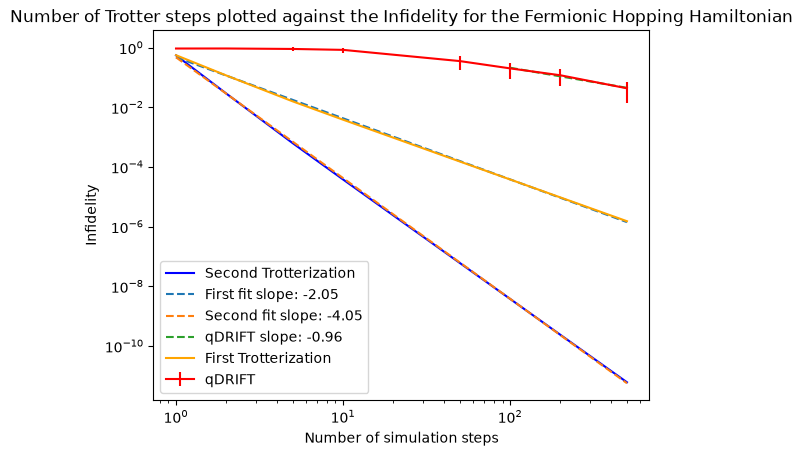

In [66]:
plt.errorbar(step_num, first_error, label = 'First Trotterization', color = 'orange')
plt.loglog(step_num, second_error, label = 'Second Trotterization', color = 'blue')
plt.loglog(step_num, first_best_fit, '--', label = f'First fit slope: {first_slope[0]:.2f}')
plt.loglog(step_num, second_best_fit, '--', label = f'Second fit slope: {second_slope[0]:.2f}')

plt.errorbar(step_num, qd_error, yerr= qd_std_dev, label = 'qDRIFT', color = 'red')
plt.loglog(step_array[mask], qd_best_fit, '--', label = f'qDRIFT slope: {qd_fit[0]:.2f}')
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Number of simulation steps')
plt.ylabel('Infidelity')
plt.title('Number of Trotter steps plotted against the Infidelity for the Fermionic Hopping Hamiltonian' )
plt.legend()
plt.show()


For sufficiently large r, the qDRIFT approachs approximately an inverse dependence on the number of samples. This is consistent with the expected stochastic behaviour. For the Trotterizations, we approximately recover the same power law as for the Ising Hamiltonian.

## Accuracy vs Circuit Cost

We will use a fake IBM backend again and follow the same procedure.

In [67]:
from qiskit import transpile
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke

backend = FakeSherbrooke()

#We will be transpiling as per the first notebook, here you can choose what seed to use
seed_transpiler = 1

In [68]:
### Trotterization

first_ecr_count = []
first_depth = []
second_ecr_count = []
second_depth = []

for n_steps in step_num:
    first_trot = ferm_first_trotterization(J, n_qubits, t, n_steps)
    second_trot = ferm_second_trotterization(J, n_qubits, t, n_steps)

    first_transpiled = transpile(first_trot, backend = backend, optimization_level = 3, seed_transpiler = seed_transpiler)
    second_transpiled = transpile(second_trot, backend = backend, optimization_level = 3, seed_transpiler = seed_transpiler)

    first_ecr_count.append(first_transpiled.count_ops().get('ecr',0))
    first_depth.append(first_transpiled.depth())
    second_ecr_count.append(second_transpiled.count_ops().get('ecr',0))
    second_depth.append(second_transpiled.depth())

#####

In [69]:
#### qDRIFT

qd_ecr_count = []
qd_ecr_dev = []
qd_depth = []
qd_depth_dev = []

for n_steps in step_num:
    ecr_per_r = []
    depth_per_r = []

    for seed in range(seed_range):
        qdrift = qDrift(H_ferm, r=n_steps, t=t, seed = seed)
        qd_transpiled = transpile(qdrift, backend=backend, optimization_level = 3, seed_transpiler= seed_transpiler)

        ecr_per_r.append(qd_transpiled.count_ops().get('ecr',0))
        depth_per_r.append(qd_transpiled.depth())

    qd_ecr_count.append(np.mean(ecr_per_r))
    qd_ecr_dev.append(np.std(ecr_per_r))
    qd_depth.append(np.mean(depth_per_r))
    qd_depth_dev.append(np.std(depth_per_r))

####

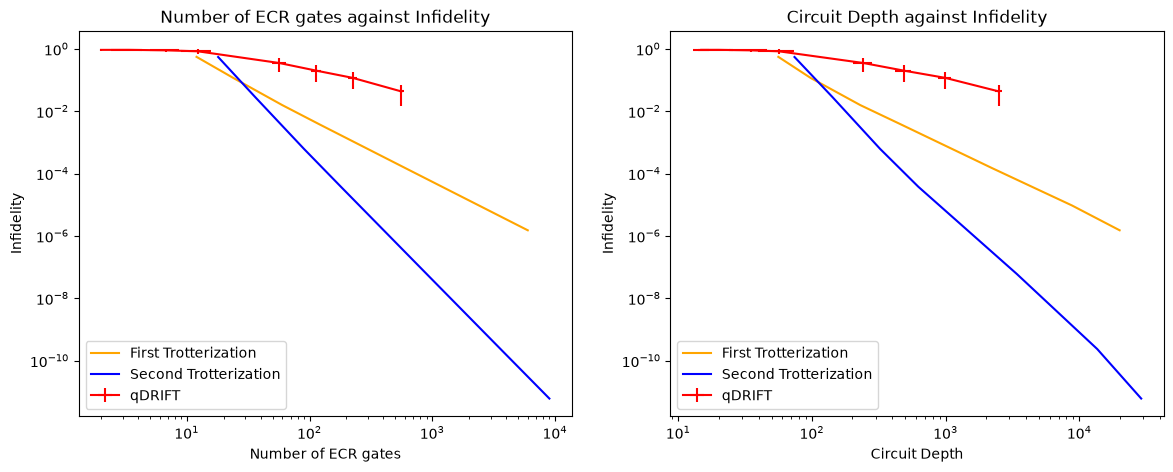

In [70]:
#### Plots

fig, ax = plt.subplots(1,2, figsize=(14, 5) )

ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].set_title('Number of ECR gates against Infidelity')
ax[0].set_xlabel('Number of ECR gates')
ax[0].set_ylabel('Infidelity')
ax[0].plot(first_ecr_count, first_error, label = 'First Trotterization', color = 'orange')
ax[0].plot(second_ecr_count, second_error, label = 'Second Trotterization', color = 'blue')
ax[0].errorbar(qd_ecr_count, qd_error, xerr= qd_ecr_dev, yerr = qd_std_dev,  label = 'qDRIFT', color = 'red')
ax[0].legend()

ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_title('Circuit Depth against Infidelity')
ax[1].set_xlabel('Circuit Depth')
ax[1].set_ylabel('Infidelity')
ax[1].plot(first_depth, first_error, label = 'First Trotterization', color = 'orange')
ax[1].plot(second_depth, second_error, label = 'Second Trotterization', color = 'blue')
ax[1].errorbar(qd_depth, qd_error, xerr= qd_depth_dev, yerr= qd_std_dev, label = 'qDRIFT', color = 'red')
ax[1].legend()

plt.show()

This graph tells us something interesting. Per step, qDRIFT uses fewer ECR gates and has a smaller circuit depth. The convergence of the Trotterizations, however, is much quicker, so we are seeing an approach with cheap individual samples, but a slow convergence, against an appraoch with more expensive steps but a faster convergence. 

## Conclusion

Overall, for this Hamiltonian, the Trotterization approach does seem to be favourable. Nevertheless, for a small circuit depth, the qDRIFT approach could prove to be competitive. The fermionic hopping Hamiltonian and the transverse Ising Hamiltonian both have a clean structure. Trotterization exploits that, whereas qDRIFT uses a stochastic approach. 